## **wildfAIre: Modelo de machine learning para la predicción de incendios forestales**
------------------------------------------------------------------

### 1. Data Understanding ✓

El objetivo de esta sección es explorar los datos contenidos en final_dataset.csv, a fin de identificar la columna target (columna 'occured') para poder ralizar la separación entre train y test.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from src.utils.data_utils import guardar_dataset, plot_distribuciones, plot_distribuciones_por_clase, plot_correlacion, plot_boxplots

In [2]:
fire_df = pd.read_csv("src/data_sample/final_dataset.csv")

# Comprobamos que los datos se han cargado correctamente
fire_df.head()

,daynight_N,lat,lon,fire_weather_index,pressure_mean,wind_direction_mean,wind_direction_std,solar_radiation_mean,dewpoint_mean,cloud_cover_mean,evapotranspiration_total,humidity_min,temp_mean,temp_range,wind_speed_max,occured,frp
0,0.0,-15.19928,38.54393,5.654271,955.608333,136.083333,43.611845,250.333333,15.883333,18.375000,4.89,35.0,23.175000,12.9,13.5,0.0,3.69
1,1.0,31.51203,-101.57546,16.564673,927.016667,181.333333,31.925260,296.916667,10.529167,3.416667,7.24,16.0,29.733333,13.4,16.2,0.0,0.73
2,1.0,-13.74538,28.05493,5.542089,884.379167,109.166667,8.379870,210.958333,6.095833,12.208333,3.68,35.0,14.104167,11.1,16.8,0.0,0.78
3,0.0,13.53091,-11.22573,7.703410,981.158333,168.416667,133.287570,244.208333,13.095833,56.458333,5.59,29.0,26.704167,12.9,11.0,0.0,8.91
4,0.0,5.61833,16.59892,16.895093,917.116667,202.208333,91.791875,266.750000,6.712500,9.166667,6.00,10.0,26.820833,16.0,16.6,0.0,5.97


In [4]:
# Exploramos el contenido de los datos
fire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118858 entries, 0 to 118857
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   daynight_N                118858 non-null  float64
 1   lat                       118858 non-null  float64
 2   lon                       118858 non-null  float64
 3   fire_weather_index        118858 non-null  float64
 4   pressure_mean             118858 non-null  float64
 5   wind_direction_mean       118858 non-null  float64
 6   wind_direction_std        118858 non-null  float64
 7   solar_radiation_mean      118858 non-null  float64
 8   dewpoint_mean             118858 non-null  float64
 9   cloud_cover_mean          118858 non-null  float64
 10  evapotranspiration_total  118858 non-null  float64
 11  humidity_min              118858 non-null  float64
 12  temp_mean                 118858 non-null  float64
 13  temp_range                118858 non-null  float64
 14 

In [4]:
data_dict = pd.DataFrame({
    'columna': fire_df.columns,
    'dtype': fire_df.dtypes.values,
    'nulos_pct': (fire_df.isnull().mean() * 100).round(1).values,
    'unicos': fire_df.nunique().values,
    'ejemplo': [fire_df[c].dropna().iloc[0] if len(fire_df[c].dropna()) > 0 else None for c in fire_df.columns]
})
data_dict

,columna,dtype,nulos_pct,unicos,ejemplo
0,daynight_N,float64,0.0,2,0.000000
1,lat,float64,0.0,117561,-15.199280
2,lon,float64,0.0,118094,38.543930
3,fire_weather_index,float64,0.0,115108,5.654271
4,pressure_mean,float64,0.0,48551,955.608333
5,wind_direction_mean,float64,0.0,7612,136.083333
6,wind_direction_std,float64,0.0,98239,43.611845
7,solar_radiation_mean,float64,0.0,6240,250.333333
8,dewpoint_mean,float64,0.0,14199,15.883333
9,cloud_cover_mean,float64,0.0,2401,18.375000


La variable target sería 'occured', siendo cero la no existencia de fuego y 1 la detección de fuego. También vemos que hay otra variable categórica con dos niveles, 'daynight_N'. 

Pasamos a realizar la división entre train y test, previa comprobación de si algún nivel de la variable target está infrarrepresentado.

<Axes: xlabel='occured', ylabel='count'>

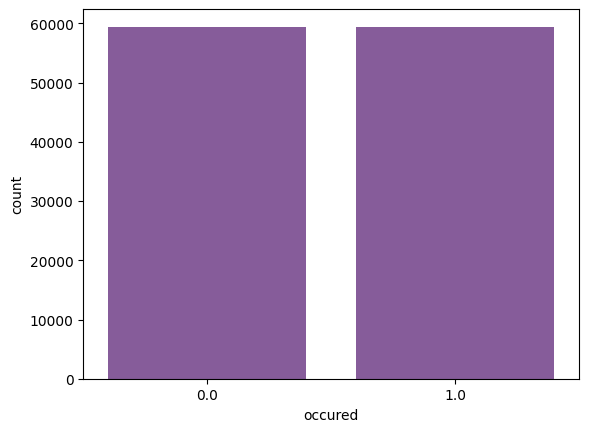

In [5]:
sns.countplot(data=fire_df, x='occured', color=plt.cm.BuPu(0.7))

In [3]:
# Definimos las columnas de features:
columnas = fire_df.columns.tolist()
X = fire_df.drop(columns=["occured"])

# La columna Target:
y = fire_df['occured']

# Y realizamos la división en dos datasets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Guardamos los nuevos dataframes:


guardar_dataset(X_train, "train")
guardar_dataset(X_test, "test")

Dataset guardado en: src/data_sample\train.csv (95086 filas, 16 columnas)
Dataset guardado en: src/data_sample\test.csv (23772 filas, 16 columnas)


'src/data_sample\\test.csv'

#### 2. EDA dirigido ✓

Como la feature 'frp' es una variable numérica que determina la intensidad del fuego producido una vez ocurre, no se trata de un dato utilizable para predecir los casos, por lo que debemos eliminarla del dataset para entrenar el modelo.

In [4]:
X_train_copy = X_train.drop(columns="frp")

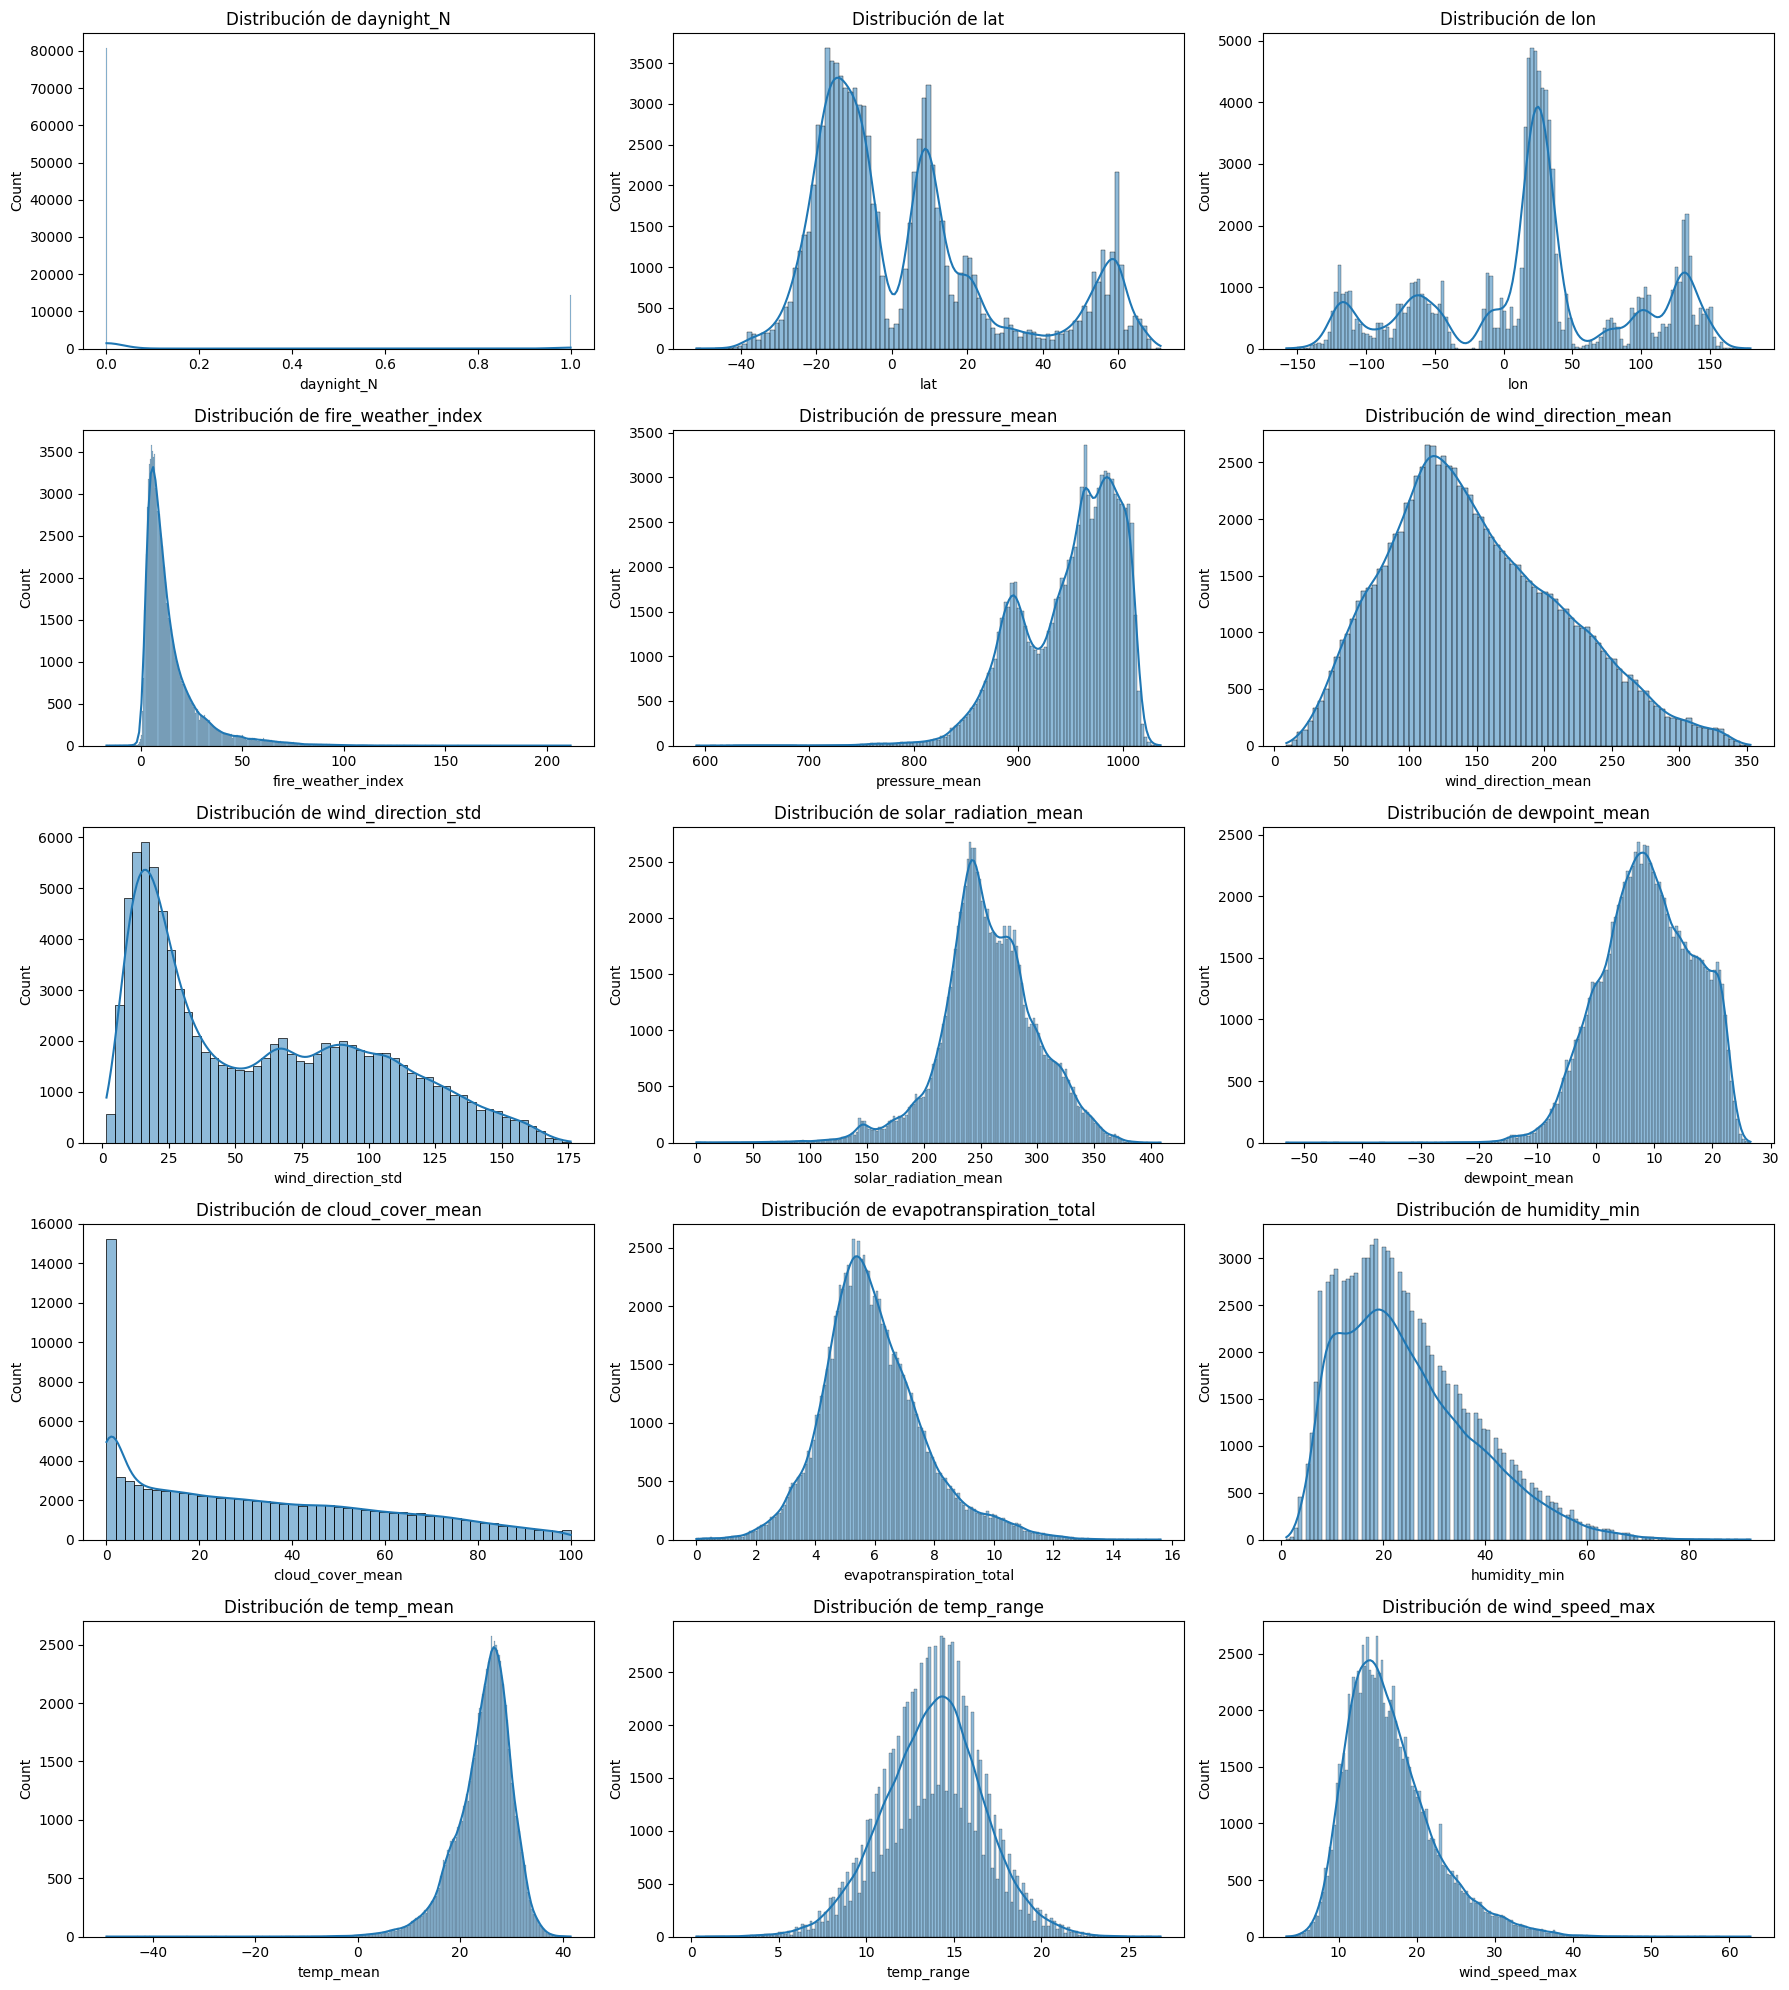

In [ ]:
# Graficar las distribuciones de las features de 'X_train'
plot_distribuciones(X_train_copy)


Vemos que no todas las features siguen una distribución normal, al igual que no todas se encuentran en el mismo rango de valores. También vemos que hay muchos más registros de noche que de día para la feature 'daynight_N'. Ahora comprobemos la distribución en base a la variable target.

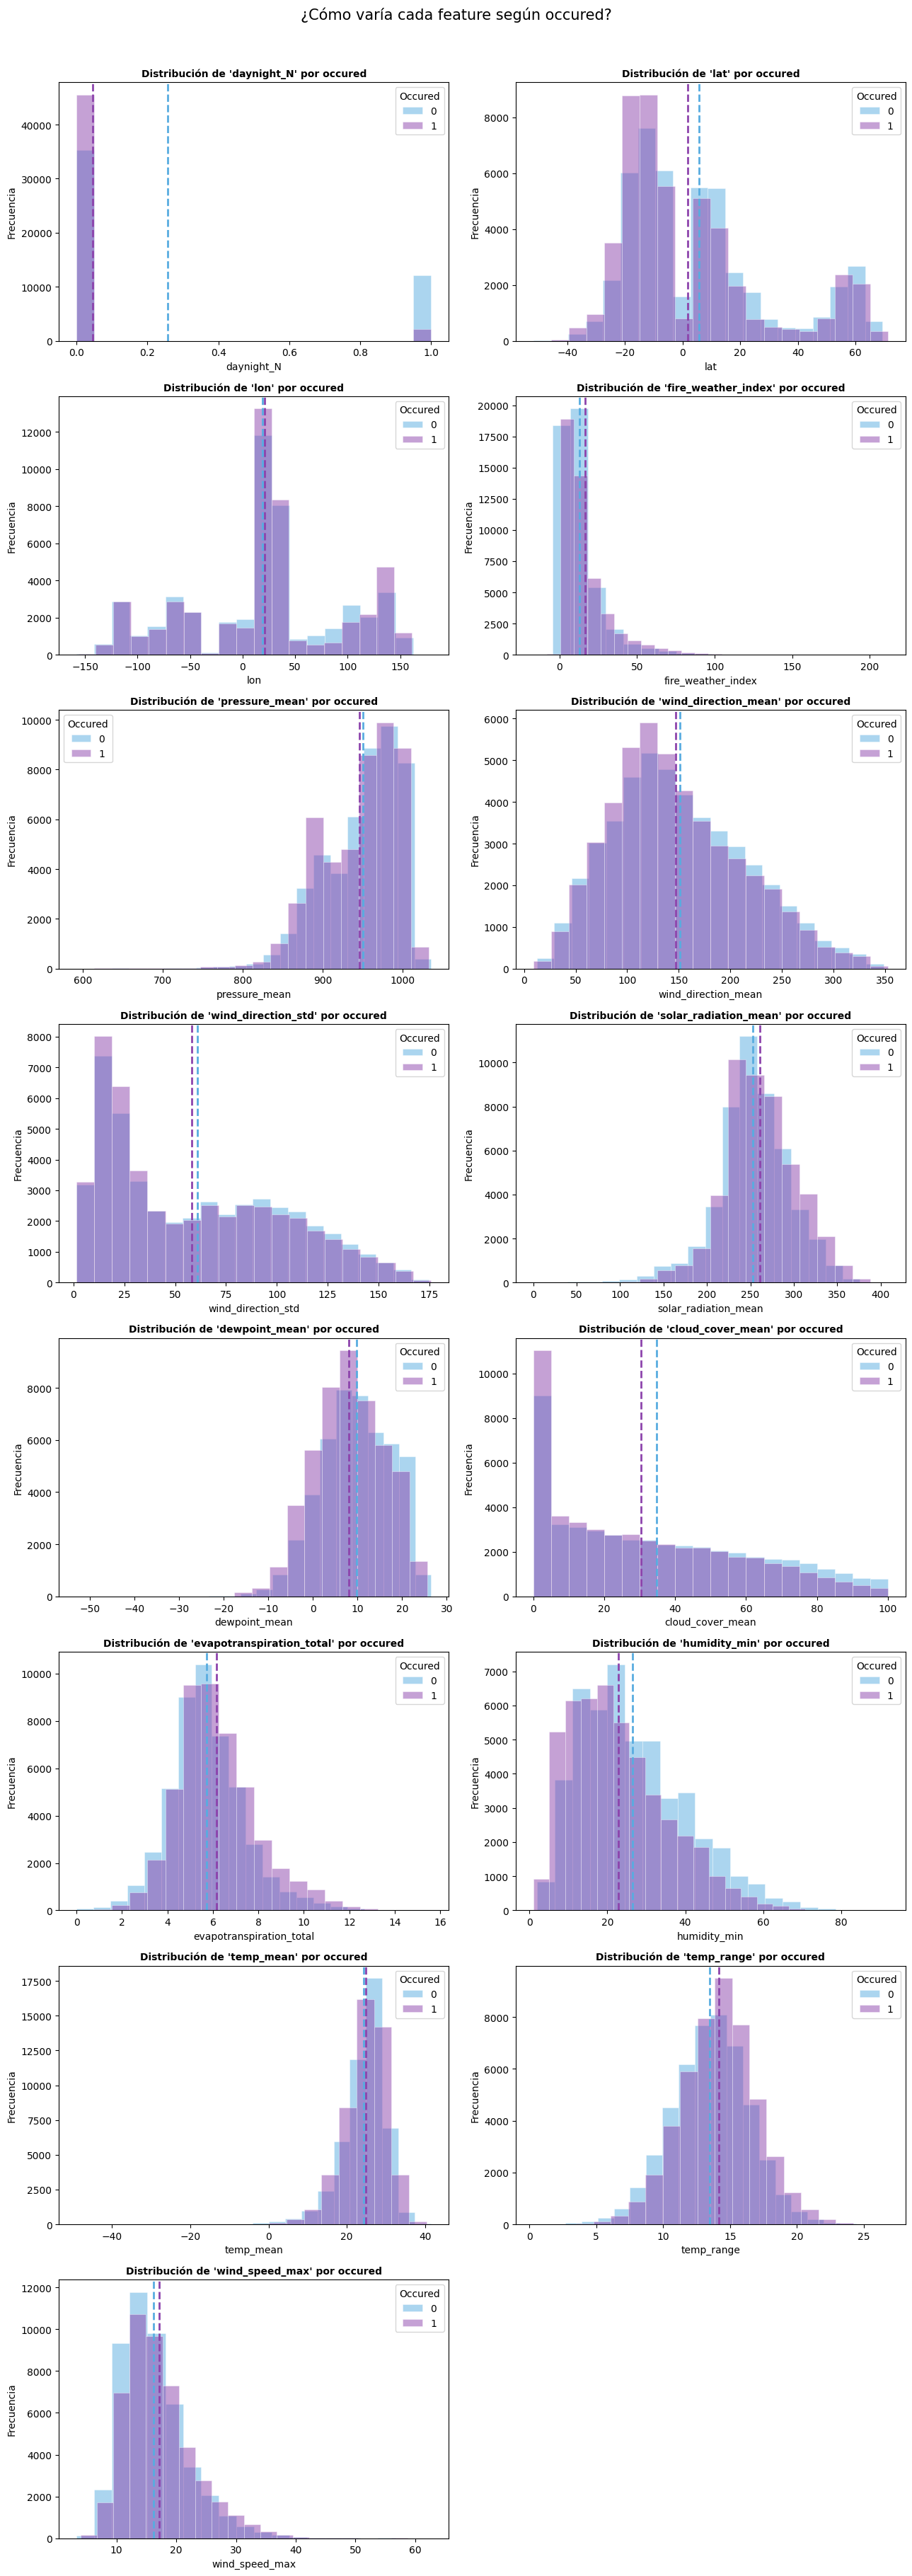

In [7]:
plot_distribuciones_por_clase(X_train_copy, y_train, target_name="occured")

Vemos que la ditribución de los rangos de valores no presentan una división clara entre los dos niveles de 'occured', a excepción de 'daynight_N', donde la mayor parte de casos registrados durante la noche se corresponden con fuegos, mientras que la mayor parte de casos ocurridos durante el día se corresponden con casos de no incendio. Para confirmar que las variables escogidas aportan datos de valor al modelo para diferenciar entre los dos niveles del target, aplicamos T-Test como medida de la significancia estadística.

In [11]:
clases = y_train.unique()

for col in X_train_copy.columns:
        grupo_0 = X_train[col][y_train == clases[0]]
        grupo_1 = X_train[col][y_train == clases[1]]
        
        t_stat, p = ttest_ind(grupo_0, grupo_1)
        print(f"{col}: t={t_stat:.2f}, p-valor={p:.5f}")

daynight_N: t=95.61, p-valor=0.00000
lat: t=23.72, p-valor=0.00000
lon: t=-5.22, p-valor=0.00000
fire_weather_index: t=-39.18, p-valor=0.00000
pressure_mean: t=13.78, p-valor=0.00000
wind_direction_mean: t=10.19, p-valor=0.00000
wind_direction_std: t=10.46, p-valor=0.00000
solar_radiation_mean: t=-32.36, p-valor=0.00000
dewpoint_mean: t=31.61, p-valor=0.00000
cloud_cover_mean: t=24.88, p-valor=0.00000
evapotranspiration_total: t=-40.31, p-valor=0.00000
humidity_min: t=42.32, p-valor=0.00000
temp_mean: t=-11.97, p-valor=0.00000
temp_range: t=-36.56, p-valor=0.00000
wind_speed_max: t=-27.08, p-valor=0.00000


Vemos que para ambos niveles todas las variables presentan diferencias significativas entre los registros de incendio y de normalidad, por lo que de momento conservamos toddas las variables. Pasemos ahora a analizar las correlaciones de los datos.

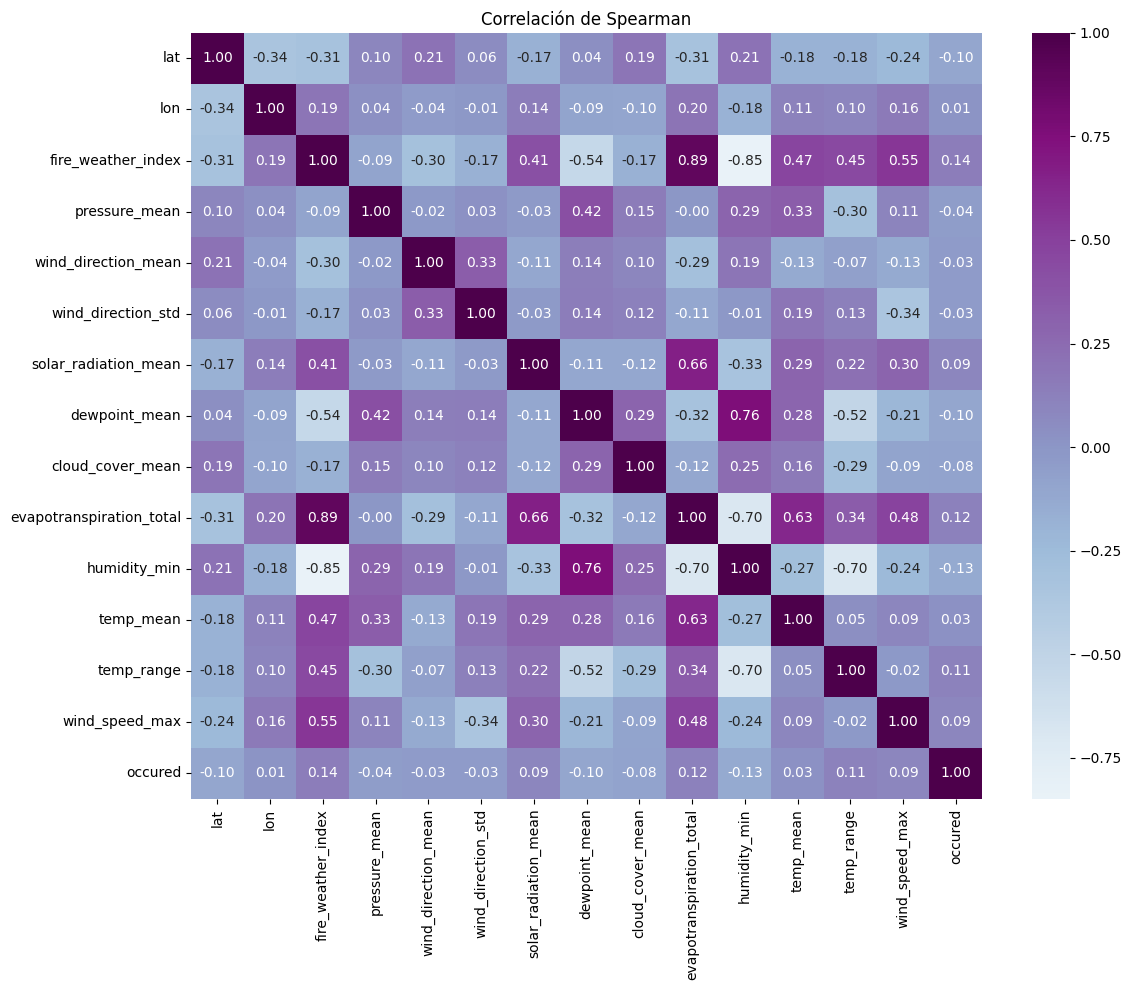

In [5]:
plot_correlacion(X_train_copy, y_train, target_name="occured", excluir="daynight_N")

La variable de evapotranspiration_total está correlacionada con la variable de fire_weather_index, solar_radiation_mean, humidity_min y temp_mean, por lo que consideramos eliminarla del dataset. Eliminamos también humidity_min al estar correlacionada con otras dos variables.

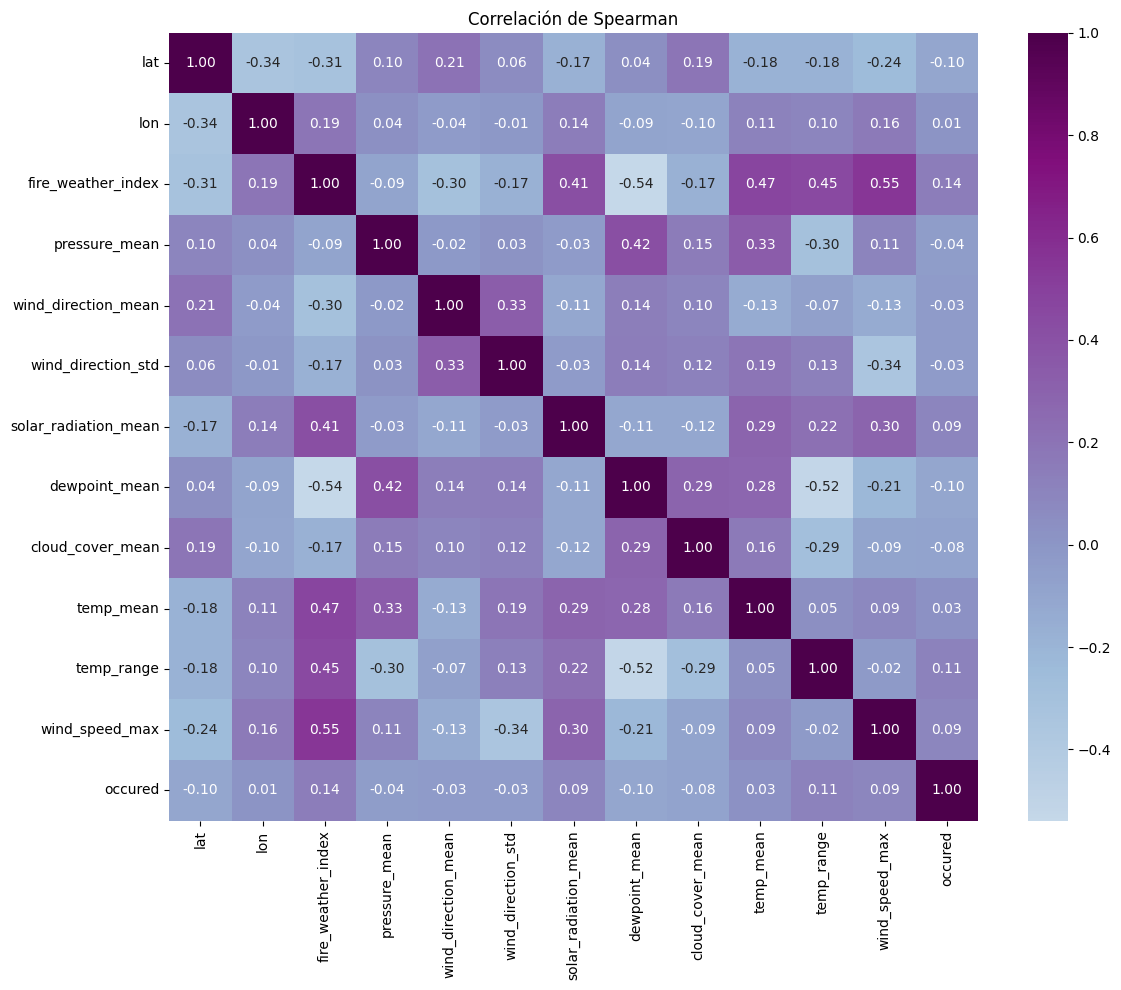

In [5]:
X_train_copy = X_train_copy.drop(columns= ["humidity_min", "evapotranspiration_total"])

plot_correlacion(X_train_copy, y_train, target_name="occured", excluir="daynight_N")

Las correlaciones mostradas ahoras están por debajo de 0.80 (no son correlaciones fuertes), por lo que podemos continuar con el análisis de outliers.

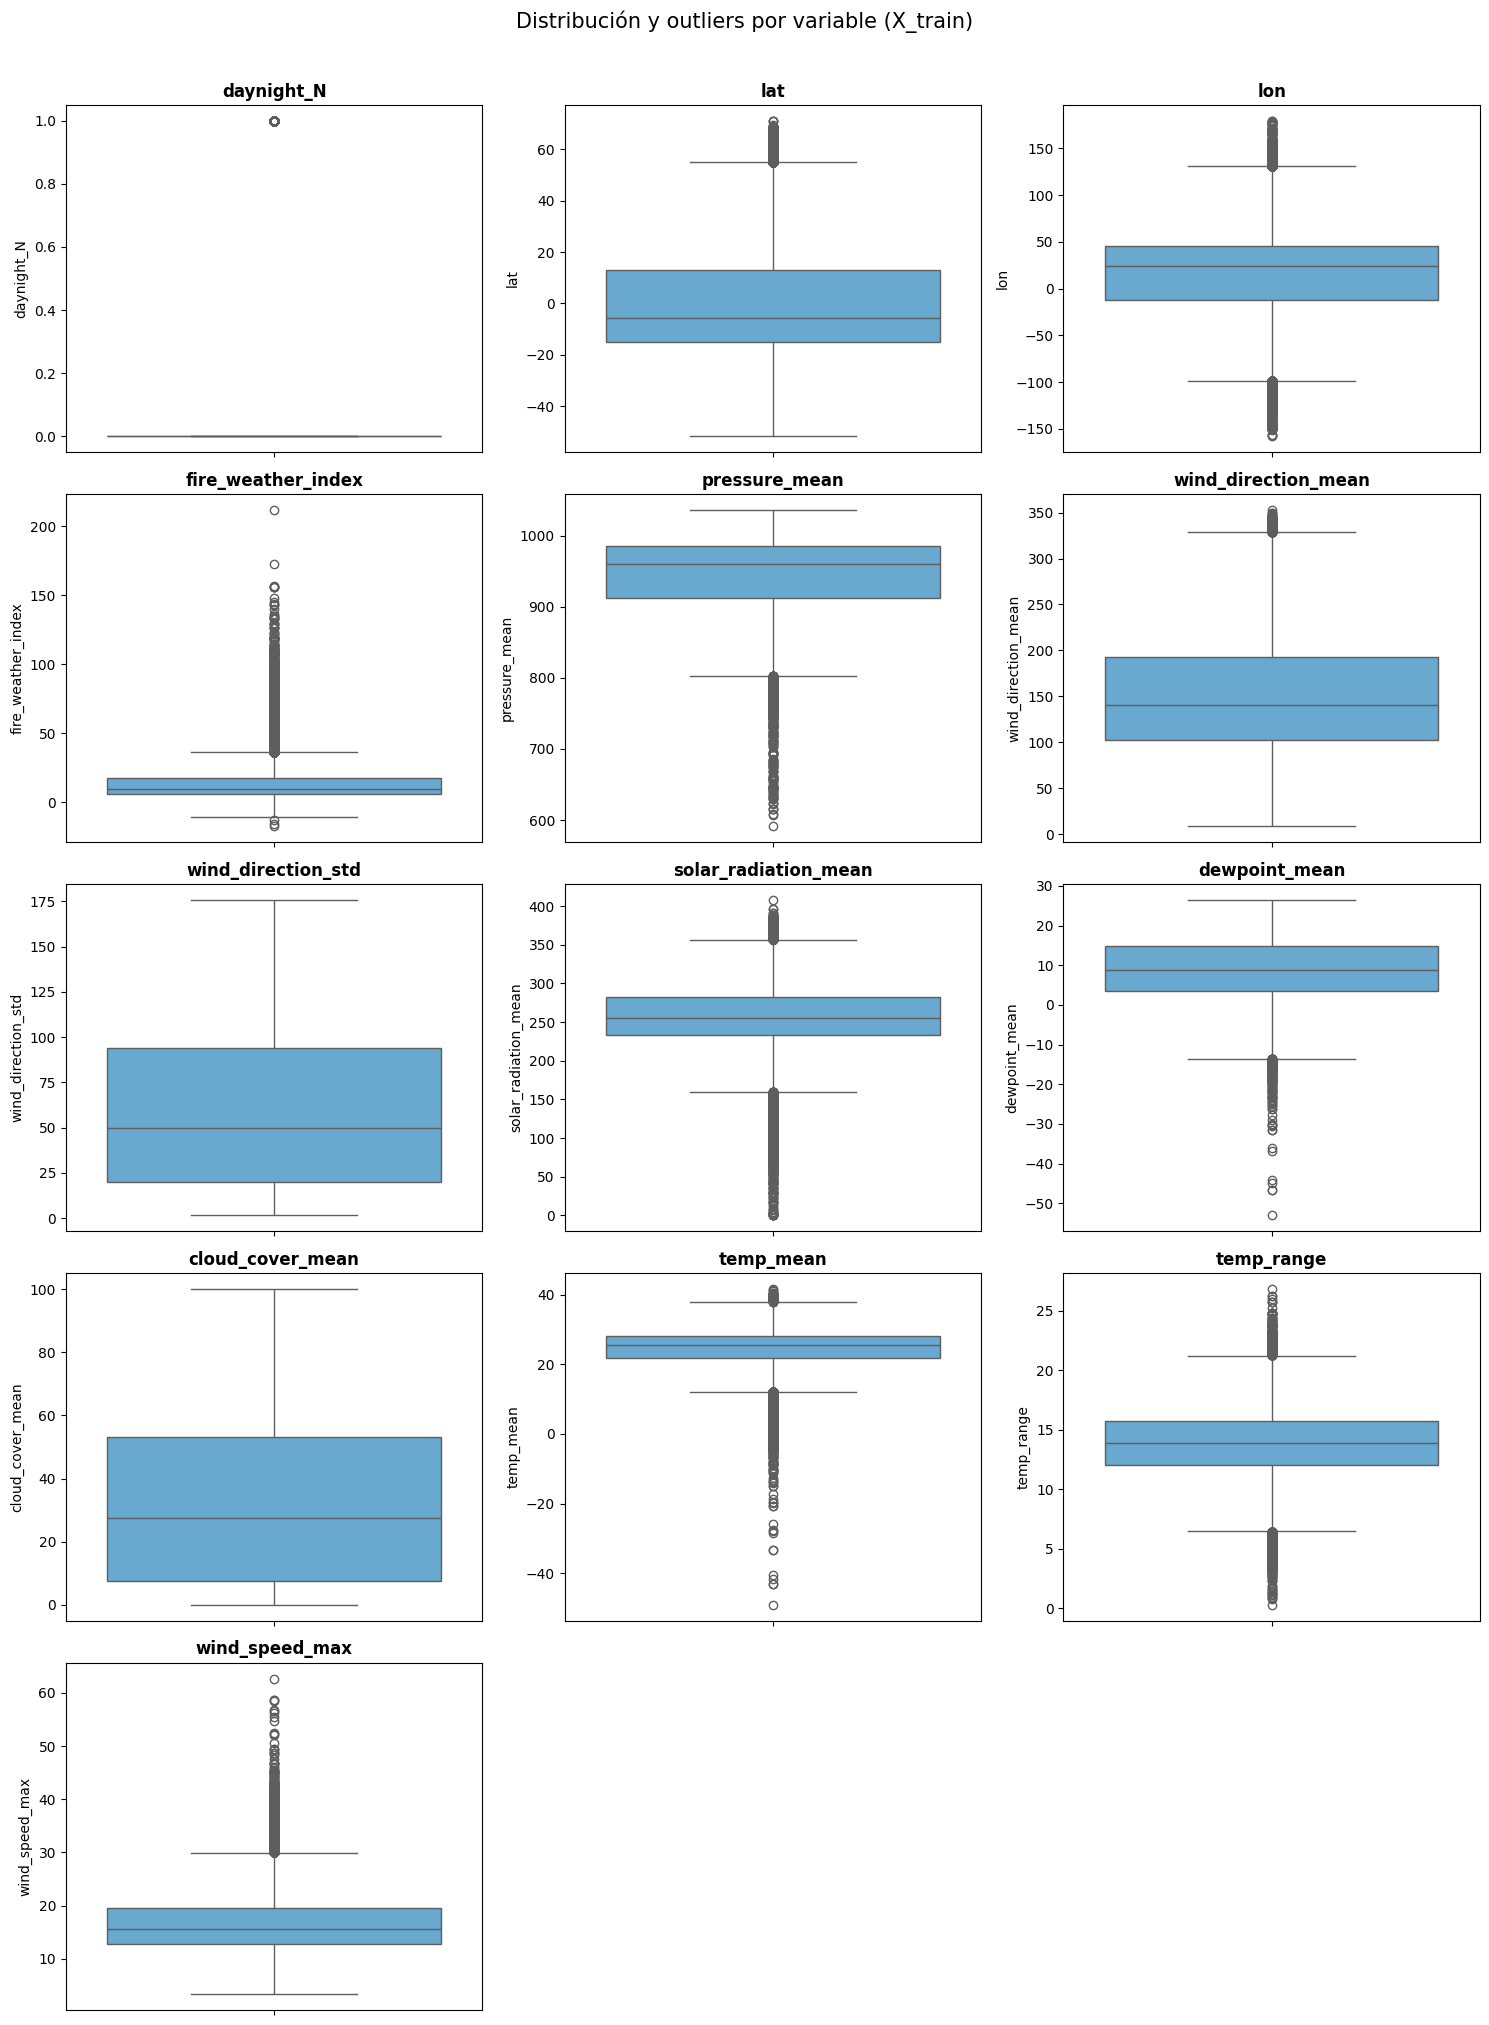

In [6]:
plot_boxplots(X_train_copy, titulo="Distribución y outliers por variable (X_train)")

Dado que sí contamos con una presencia significativa de outliers, tendremos que elegir modelos que no sean muy sensibles a su presencia o transformar los datos para pasarlos por modelos que sí se vean afectados por estas condiciones. Vamos a realizar una estandarización de los datos para guardarlos en una versión alternativa de X_train, para usarla en el estudio del baseline para el modelo.

#### 3. Feature Engineering ✓

#### 4. Preprocesado ✓

#### 5. Modelado ✓

#### 6. Optimización ✓

#### 7. Evaluación final ✓